In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv

load_dotenv()

model = ChatGroq(model_name="openai/gpt-oss-20b")

In [2]:
import requests
import os


# test script got get all available models
api_key = os.environ.get("GROQ_API_KEY")
url = "https://api.groq.com/openai/v1/models"

headers = {
    "Authorization": f"Bearer {api_key}",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

print(response.json())

{'object': 'list', 'data': [{'model_card': 'https://openai.com/index/gpt-oss-model-card', 'id': 'openai/gpt-oss-20b', 'object': 'model', 'created': 1754407957, 'owned_by': 'OpenAI', 'active': True, 'context_window': 131072, 'public_apps': None, 'max_completion_tokens': 65536, 'hugging_face_id': 'openai/gpt-oss-20b', 'name': 'GPT OSS 20B', 'input_modalities': ['text'], 'output_modalities': ['text'], 'context_length': 131072, 'max_output_length': 65536, 'pricing': {'prompt': '0.000000075', 'completion': '0.0000003', 'image': '0', 'request': '0', 'input_cache_read': '0.0000000375'}, 'supported_sampling_parameters': ['temperature', 'top_p', 'stop', 'seed', 'max_tokens'], 'supported_features': ['tools', 'json_mode', 'structured_outputs', 'reasoning']}, {'model_card': 'https://huggingface.co/openai/whisper-large-v3', 'id': 'whisper-large-v3', 'object': 'model', 'created': 1693721698, 'owned_by': 'OpenAI', 'active': True, 'context_window': 448, 'public_apps': None, 'max_completion_tokens': 44

In [15]:
from tavily import TavilyClient
from typing import Literal, Dict, Any
from langchain_core.tools import tool
searchClient = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

@tool
def web_search(query: str, max_results: int = 2, topics: Literal["general", "news", "finance" ] = "general", include_raw_content: bool = True) -> Dict[str, Any]:
    """web search tool that reterives the data from web"""
    return searchClient.search(query=query, topic=topics, max_results= 1, include_raw_content=include_raw_content)

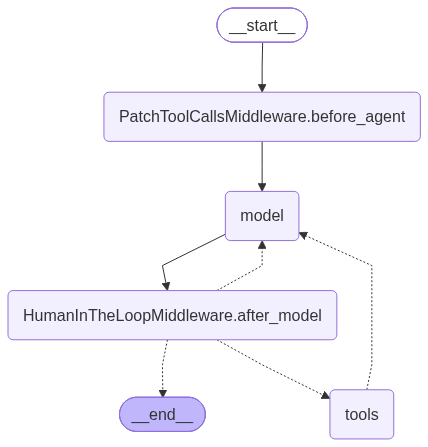

In [25]:
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver


backend = FilesystemBackend(root_dir="../agentMemory")
checkpointer = MemorySaver()

deepagent = create_deep_agent(
    model=model,
    system_prompt="You are research administrator {provide response in 5 to 10 words} dont't exceed the size of text in every case",
    tools=[web_search],
    backend = backend,
    checkpointer = checkpointer,
    interrupt_on={"web_search": {
        "allowed_decisions": ["approve", "reject", "edit"]
    }}
)
deepagent


In [26]:
config = {
    "configurable":{
        "thread_id": 22
    },
    "recursion_limit": 25
}

result = deepagent.invoke(input={
    "messages":["what is the latest ai news of today right now (answer in 5 to 10 words)"]
}, config=config)
print(result["messages"][-1].content)

In [28]:
result

{'messages': [HumanMessage(content='what is the latest ai news of today right now (answer in 5 to 10 words)', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Need latest AI news. Likely need web_search.', 'tool_calls': [{'id': 'fc_be02d6ea-eb05-4db7-bdaf-980108cefc30', 'function': {'arguments': '{"include_raw_content":true,"max_results":5,"query":"latest AI news today"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 2018, 'total_tokens': 2067, 'completion_time': 0.055250017, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.11946075, 'prompt_tokens_details': None, 'queue_time': 0.307163253, 'total_time': 0.174710767}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a12747-de2c-7ff2-a

In [29]:
from langgraph.types import Command


response = Command(
    resume={
        "decisions": [
            {
                "type": "edit",
                "edited_action": {
                    "name": "web_search", 
                    "args": {"query": "what is the latest price of BMW x7 (answer in 5 to 10 words)"}
                }
            }
        ]
    }
)


result = deepagent.invoke(response, config=config)
result

{'messages': [HumanMessage(content='what is the latest ai news of today right now (answer in 5 to 10 words)', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Need latest AI news. Likely need web_search.', 'tool_calls': [{'id': 'fc_be02d6ea-eb05-4db7-bdaf-980108cefc30', 'function': {'arguments': '{"include_raw_content":true,"max_results":5,"query":"latest AI news today"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 2018, 'total_tokens': 2067, 'completion_time': 0.055250017, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.11946075, 'prompt_tokens_details': None, 'queue_time': 0.307163253, 'total_time': 0.174710767}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_9b8528b477', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a12747-de2c-7ff2-a

In [30]:
from langgraph.types import Command

response = Command(
    resume={
        "decisions": [
            {
                "type": "approve"
            }
        ]
    }
)

result = deepagent.invoke(response, config=config)
result

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-20b` in organization `org_01m4jqkfz9erttrhz3rzqn3fp2` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 10604, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}